In [18]:
import qse
import snag
import qkernel
import numpy as np
import matplotlib.pyplot as plt

In [19]:
qbits_ref = qse.Qbits(np.array([[0.], [1.]]))
rng = np.random.RandomState(4)

def gen_qbits(n):
    qs = []

    for _ in range(n):
        qbits = qbits_ref.copy()
        qbits.rattle(0.1, rng=rng)
        qs.append(qbits)

    return qs

def compute_probs(qs, scaling_fac = 10):
    c = np.array([q.positions for q in qs])
    c *= scaling_fac 

    ham = qkernel.hamiltonian.QuTiPHamiltonian(c)
    sim = qkernel.simulator.QuTiPSimulator(ham.generate_hamiltonians_list())
    return np.array(sim.get_probabilities_list())[:, :, 0]

In [31]:
n_train = 200
q_train = gen_qbits(n_train)
p_train = compute_probs(q_train)

n_test = 10
q_test = gen_qbits(n_test)
p_test = compute_probs(q_test)

print(p_train.shape, p_test.shape)

(200, 4) (10, 4)


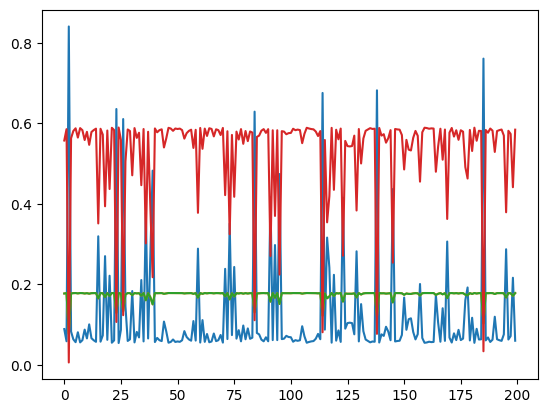

In [32]:
plt.plot(p_train[:, 0])
plt.plot(p_train[:, 1])
plt.plot(p_train[:, 2])
plt.plot(p_train[:, 3])

In [33]:
def radial_hopping(r):
    return 1. / r**3

In [ ]:
# calc = snag.Hubbard(n_up=1, n_dn=1, n_sites=qbits_ref.nqbits)
# print(calc)

spin_z=0, dim=4


In [13]:
kernel = qkernel.kernel.Kernel(p_train=p_train, p_test=p_test)
g_train = kernel.compute_gram_train()
g_test = kernel.compute_gram_test()

In [14]:
from sklearn.kernel_ridge import KernelRidge

In [ ]:
model = KernelRidge(kernel="precomputed")
model.train